### Эксперименты с моделями глубокого обучения (Deep Learning)
В рамках данного ноутбука проводится серия экспериментов по обучению моделей глубокого обучения, включая:
- TabNet
- GANDALF

Основная цель исследования — определить, способны ли модели глубокого обучения показывать более высокое качество на данной задаче по сравнению с классическими алгоритмами машинного обучения, такими как CatBoost. Для обеспечения корректности сравнения данные были подготовлены и обработаны одинаковым образом для всех моделей.

Каждая из выбранных моделей будет обучена с несколькими наборами гиперпараметров и различными архитектурными конфигурациями, чтобы оценить, насколько подходы Deep Learning действительно подходят для решения поставленной задачи.

In [1]:
import importlib
import logging
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from pipeline import constants as C
from pipeline.features import FeatureCols, generate_features
from pipeline.optimize import hyperparameter_search, hyperparameter_search_gandalf
from pipeline.preprocess import get_cat_idxs_dims, preprocess, split_data
from pipeline.train import train_tabnet_per_class
from pipeline.train_pytorch_tabular import train_pytorch_tabular_per_class
from pipeline.utils import seed_everything

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
)

seed_everything(C.SEED)
warnings.filterwarnings("ignore")

2026-05-07 16:58:45 - INFO - Seed установлен: 42


### Загрузка и предобработка данных
На данном этапе выполняется загрузка исходных данных и их подготовка к обучению моделей. Предобработка проводилась по той же схеме, что и в предыдущих экспериментах — это обеспечивает корректность сравнения результатов.

In [2]:
# загружаем данные
raw_df = pd.read_pickle(C.RAW_DATA_FILE)
print(f"Размер датасета до предобработки: {raw_df.shape}")

# предобрабатываем
df = preprocess(raw_df)
print(f"Размер датасета после предобработки: {df.shape}")

2026-05-07 16:59:06 - INFO - Начало предобработки данных, размер: (12766, 21)
2026-05-07 16:59:06 - INFO - Удалено строк с некорректным сочетанием NORM: 326
2026-05-07 16:59:07 - INFO - Предобработка завершена, финальный размер: (12311, 19)
2026-05-07 16:59:07 - INFO - Распределение классов:
combo_class
N       5917
S       1391
M       1060
C       1007
MC       692
HS       384
H        354
MS       334
CS       273
MHS      213
HC       164
MCS      137
HCS      128
MHCS     107
MH        94
MHC       56


Размер датасета до предобработки: (12766, 21)
Размер датасета после предобработки: (12311, 19)


In [3]:
# баланс суперклассов 
for sc in C.SUPERCLASSES:
    n_pos = int(df[sc].sum())
    n_neg = len(df) - n_pos
    print(f"{sc}: pos={n_pos} ({n_pos/len(df):.1%}), neg={n_neg} ({n_neg/len(df):.1%}), ratio={n_neg/n_pos:.1f}:1")

CD: pos=2564 (20.8%), neg=9747 (79.2%), ratio=3.8:1
HYP: pos=1500 (12.2%), neg=10811 (87.8%), ratio=7.2:1
MI: pos=2693 (21.9%), neg=9618 (78.1%), ratio=3.6:1
NORM: pos=5917 (48.1%), neg=6394 (51.9%), ratio=1.1:1
STTC: pos=2967 (24.1%), neg=9344 (75.9%), ratio=3.1:1


### Генерация признаков
Сгенерируем признаки на которых обучался Catboost из предыдущих экспериментов

| Группа | Описание | Кол-во |
|--------|----------|--------|
| **Демографические** | age, sex, height, weight, bmi | 5 |
| **Ось сердца (OHE)** | heart_axis_* | ~9 |
| **ЭКГ-сигнал (12 отведений)** | Статистика, частоты (Welch), IQR, MAD, ZCR, автокорреляция, производная, межотводные корреляции | ~220 |


In [4]:
# генерируем признаки (занимает несколько минут, результат кэшируется в datasets/features_cache.pkl)
df_features, feat_cols = generate_features(df, n_jobs=-1, cache_path="datasets/features_cache.pkl")

print(f"\nМатрица признаков: {df_features.shape}")
print(f"Демографические   : {len(feat_cols.base)}")
print(f"Ось сердца (OHE)  : {len(feat_cols.heart_axis)}")
print(f"ЭКГ-признаки      : {len(feat_cols.ecg)}")
print(f"Итого признаков   : {len(feat_cols.all)}")

2026-05-07 16:59:10 - INFO - Загрузка признаков из кэша: datasets/features_cache.pkl



Матрица признаков: (12311, 385)
Демографические   : 5
Ось сердца (OHE)  : 10
ЭКГ-признаки      : 358
Итого признаков   : 373


### Train/Test Split
Используем столбец `strat_fold` для разбиения данных на train/test:
- Фолды 1–7 → train
- Фолды 8 → validation
- Фолды 9–10 → test

In [5]:
# train (фолды 1–7) / val (фолд 8) / test (фолды 9–10)
train_feat_df, val_feat_df, test_feat_df = split_data(df_features)
features = feat_cols.all

# TabNet не требует cat_idxs для OHE-столбцов (они уже числовые 0/1)
cat_idxs = []
cat_dims = []

print(f"Признаков для обучения : {len(features)}")
print(f"Обучающая выборка      : {train_feat_df.shape}  (фолды 1–7)")
print(f"Валидационная выборка  : {val_feat_df.shape}    (фолд 8)")
print(f"Тестовая выборка       : {test_feat_df.shape}   (фолды 9–10)")
print(f"\nПервые 10 признаков: {features[:10]}")

2026-05-07 16:59:12 - INFO - Разбивка: train=7975, val=1152, test=3184 строк


Признаков для обучения : 373
Обучающая выборка      : (7975, 385)  (фолды 1–7)
Валидационная выборка  : (1152, 385)    (фолд 8)
Тестовая выборка       : (3184, 385)   (фолды 9–10)

Первые 10 признаков: ['age', 'sex', 'height', 'weight', 'bmi', 'heart_axis_ALAD', 'heart_axis_ARAD', 'heart_axis_AXL', 'heart_axis_AXR', 'heart_axis_LAD']


2026-05-07 16:59:14 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-07 16:59:14 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


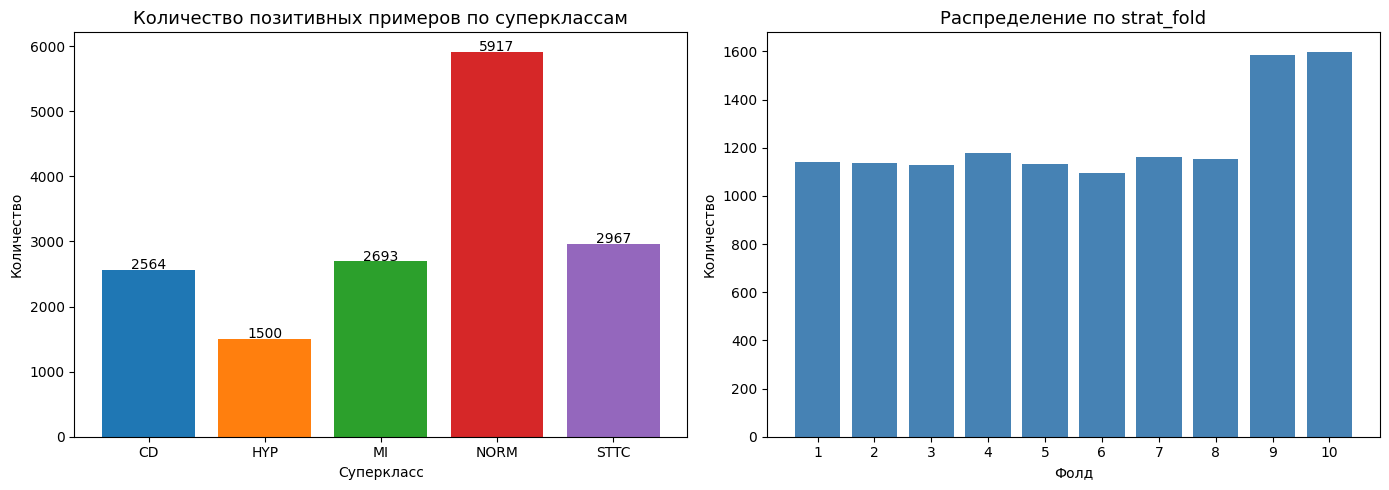

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# количество позитивных примеров по суперклассам
sc_counts = {sc: int(df[sc].sum()) for sc in C.SUPERCLASSES}
axes[0].bar(sc_counts.keys(), sc_counts.values(), color=sns.color_palette("tab10", len(C.SUPERCLASSES)))
axes[0].set_title("Количество позитивных примеров по суперклассам", fontsize=13)
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Количество")
for i, (k, v) in enumerate(sc_counts.items()):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=10)

# распределение по фолдам
fold_counts = df[C.FOLD_COL].value_counts().sort_index()
axes[1].bar(fold_counts.index.astype(str), fold_counts.values, color="steelblue")
axes[1].set_title("Распределение по strat_fold", fontsize=13)
axes[1].set_xlabel("Фолд")
axes[1].set_ylabel("Количество")

plt.tight_layout()
plt.show()

### TabNet | Базовая конфигурация
В ходе предыдущих экспериментов было установлено, что обучение отдельной модели для каждого класса даёт лучшие результаты, чем единая мультиклассовая модель. Этот подход принят как стандартный для всех последующих экспериментов. 

Начнем с модели [TabNet](https://github.com/dreamquark-ai/tabnet)

In [10]:
# параметры TabNet — конфигурация 1 (базовая)
params_exp1 = C.TABNET_PARAMS_DEFAULT.copy()
print("Параметры TabNet — конфигурация 1 (базовая):")
for k, v in params_exp1.items():
    print(f"  {k}: {v}")

Параметры TabNet — конфигурация 1 (базовая):
  n_d: 8
  n_a: 8
  n_steps: 3
  n_shared: 2
  cat_emb_dim: 1
  lr: 0.02
  mask_type: entmax
  lambda_sparse: 0.001
  max_epochs: 100
  patience: 15


In [11]:
seed_everything(C.SEED)

# обучаем и оцениваем модель TabNet для каждого класса
result_exp1 = train_tabnet_per_class(
    train_df=train_feat_df,
    val_df=val_feat_df,
    test_df=test_feat_df,
    params=params_exp1,
    features=features,
    experiment_id="exp1_default",
    verbose=1,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
)

print(f"\nMean Val F1-macro: {result_exp1['mean_val_f1_macro']:.4f}")
print(f"Mean Test F1-macro: {result_exp1['mean_test_f1_macro']:.4f}")
print(f"Mean Test PR-AUC: {result_exp1['mean_test_pr_auc']:.4f}")
print(f"Mean Test ROC-AUC: {result_exp1['mean_test_roc_auc']:.4f}")
print(f"Время обучения: {result_exp1['train_time']:.1f}с")

2026-05-07 16:59:46 - INFO - Seed установлен: 42
2026-05-07 16:59:46 - INFO - [exp1_default] Обучение 5 бинарных TabNet-моделей


epoch 0  | loss: 0.79994 | valid_accuracy: 0.21441 |  0:00:01s
epoch 1  | loss: 0.65421 | valid_accuracy: 0.76997 |  0:00:02s
epoch 2  | loss: 0.59982 | valid_accuracy: 0.7283  |  0:00:03s
epoch 3  | loss: 0.54777 | valid_accuracy: 0.55903 |  0:00:04s
epoch 4  | loss: 0.51878 | valid_accuracy: 0.75347 |  0:00:05s
epoch 5  | loss: 0.48216 | valid_accuracy: 0.81858 |  0:00:06s
epoch 6  | loss: 0.4737  | valid_accuracy: 0.82031 |  0:00:07s
epoch 7  | loss: 0.44162 | valid_accuracy: 0.82812 |  0:00:08s
epoch 8  | loss: 0.4363  | valid_accuracy: 0.83507 |  0:00:09s
epoch 9  | loss: 0.43079 | valid_accuracy: 0.8533  |  0:00:10s
epoch 10 | loss: 0.40788 | valid_accuracy: 0.8559  |  0:00:11s
epoch 11 | loss: 0.40708 | valid_accuracy: 0.86458 |  0:00:12s
epoch 12 | loss: 0.39019 | valid_accuracy: 0.86372 |  0:00:13s
epoch 13 | loss: 0.38148 | valid_accuracy: 0.85851 |  0:00:14s
epoch 14 | loss: 0.37501 | valid_accuracy: 0.86979 |  0:00:15s
epoch 15 | loss: 0.37515 | valid_accuracy: 0.87153 |  0

2026-05-07 17:00:25 - INFO - [exp1_default/CD] Val F1-macro=0.7845  PR-AUC=0.7170  best_epoch=22


epoch 0  | loss: 0.80054 | valid_accuracy: 0.11719 |  0:00:00s
epoch 1  | loss: 0.6541  | valid_accuracy: 0.19271 |  0:00:01s
epoch 2  | loss: 0.57621 | valid_accuracy: 0.32205 |  0:00:02s
epoch 3  | loss: 0.53026 | valid_accuracy: 0.20573 |  0:00:04s
epoch 4  | loss: 0.48796 | valid_accuracy: 0.16493 |  0:00:05s
epoch 5  | loss: 0.45805 | valid_accuracy: 0.18403 |  0:00:06s
epoch 6  | loss: 0.46479 | valid_accuracy: 0.34722 |  0:00:08s
epoch 7  | loss: 0.43478 | valid_accuracy: 0.36892 |  0:00:10s
epoch 8  | loss: 0.43644 | valid_accuracy: 0.68142 |  0:00:12s
epoch 9  | loss: 0.42478 | valid_accuracy: 0.48785 |  0:00:13s
epoch 10 | loss: 0.42146 | valid_accuracy: 0.53125 |  0:00:15s
epoch 11 | loss: 0.41112 | valid_accuracy: 0.71354 |  0:00:17s
epoch 12 | loss: 0.39083 | valid_accuracy: 0.70139 |  0:00:18s
epoch 13 | loss: 0.38353 | valid_accuracy: 0.6901  |  0:00:19s
epoch 14 | loss: 0.39037 | valid_accuracy: 0.74566 |  0:00:21s
epoch 15 | loss: 0.36965 | valid_accuracy: 0.65799 |  0

2026-05-07 17:01:34 - INFO - [exp1_default/HYP] Val F1-macro=0.7260  PR-AUC=0.5465  best_epoch=46


...

epoch 0  | loss: 0.71034 | valid_accuracy: 0.48003 |  0:00:00s
epoch 1  | loss: 0.65874 | valid_accuracy: 0.48958 |  0:00:02s
epoch 2  | loss: 0.61954 | valid_accuracy: 0.49566 |  0:00:03s
epoch 3  | loss: 0.57154 | valid_accuracy: 0.51389 |  0:00:04s
epoch 4  | loss: 0.55104 | valid_accuracy: 0.4974  |  0:00:06s
epoch 5  | loss: 0.54014 | valid_accuracy: 0.51736 |  0:00:08s
epoch 6  | loss: 0.51925 | valid_accuracy: 0.50087 |  0:00:10s
epoch 7  | loss: 0.49982 | valid_accuracy: 0.52951 |  0:00:12s
epoch 8  | loss: 0.48863 | valid_accuracy: 0.54601 |  0:00:14s
epoch 9  | loss: 0.47193 | valid_accuracy: 0.52604 |  0:00:16s
epoch 10 | loss: 0.47304 | valid_accuracy: 0.57986 |  0:00:17s
epoch 11 | loss: 0.45105 | valid_accuracy: 0.6059  |  0:00:19s
epoch 12 | loss: 0.44585 | valid_accuracy: 0.60417 |  0:00:20s
epoch 13 | loss: 0.43642 | valid_accuracy: 0.62587 |  0:00:21s
epoch 14 | loss: 0.42036 | valid_accuracy: 0.63194 |  0:00:22s
epoch 15 | loss: 0.41304 | valid_accuracy: 0.65538 |  0

2026-05-07 17:03:39 - INFO - [exp1_default/NORM] Val F1-macro=0.8151  PR-AUC=0.8692  best_epoch=70


epoch 0  | loss: 0.78991 | valid_accuracy: 0.24306 |  0:00:00s
epoch 1  | loss: 0.70127 | valid_accuracy: 0.24826 |  0:00:01s
epoch 2  | loss: 0.67864 | valid_accuracy: 0.34722 |  0:00:02s
epoch 3  | loss: 0.65433 | valid_accuracy: 0.25694 |  0:00:03s
epoch 4  | loss: 0.61466 | valid_accuracy: 0.35156 |  0:00:04s
epoch 5  | loss: 0.60083 | valid_accuracy: 0.2691  |  0:00:05s
epoch 6  | loss: 0.57842 | valid_accuracy: 0.26476 |  0:00:06s
epoch 7  | loss: 0.56858 | valid_accuracy: 0.26997 |  0:00:07s
epoch 8  | loss: 0.55573 | valid_accuracy: 0.2526  |  0:00:08s
epoch 9  | loss: 0.54769 | valid_accuracy: 0.26042 |  0:00:08s
epoch 10 | loss: 0.53525 | valid_accuracy: 0.27951 |  0:00:09s
epoch 11 | loss: 0.52412 | valid_accuracy: 0.30035 |  0:00:10s
epoch 12 | loss: 0.51825 | valid_accuracy: 0.3724  |  0:00:11s
epoch 13 | loss: 0.50669 | valid_accuracy: 0.40712 |  0:00:12s
epoch 14 | loss: 0.50423 | valid_accuracy: 0.46094 |  0:00:13s
epoch 15 | loss: 0.48041 | valid_accuracy: 0.49566 |  0

2026-05-07 17:04:42 - INFO - [exp1_default/STTC] Val F1-macro=0.7301  PR-AUC=0.5969  best_epoch=59
2026-05-07 17:04:42 - INFO - [exp1_default] Mean Val F1-macro=0.7479  Mean Test F1-macro=0.7351



Mean Val F1-macro: 0.7479
Mean Test F1-macro: 0.7351
Mean Test PR-AUC: 0.6335
Mean Test ROC-AUC: 0.8369
Время обучения: 293.1с


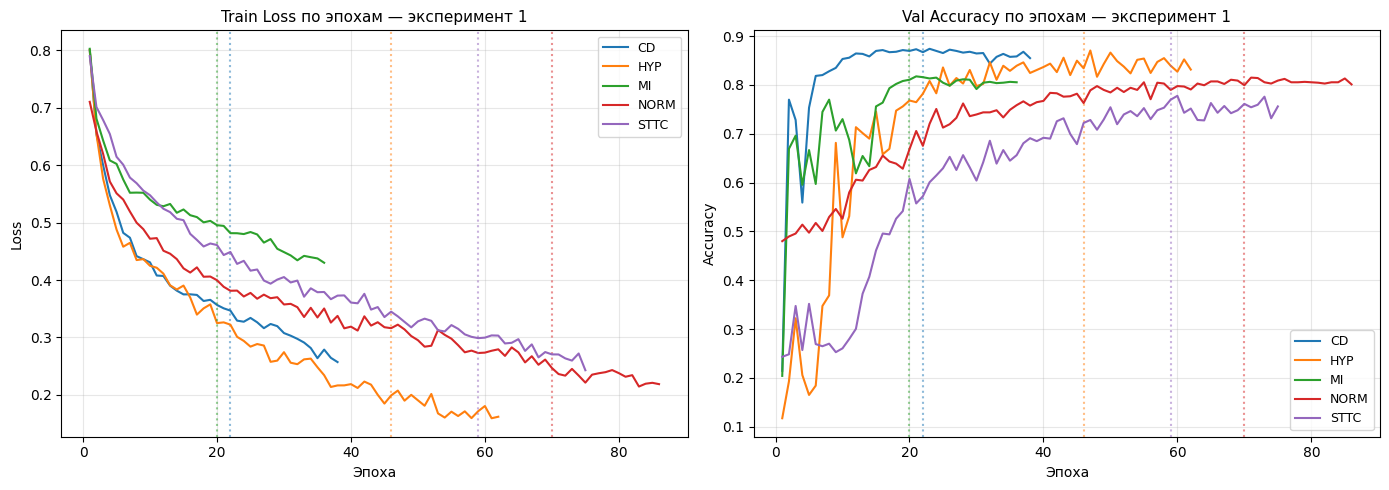

In [14]:
# кривые обучения — эксперимент 1
colors_sc = sns.color_palette("tab10", len(C.SUPERCLASSES))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sc, color in zip(C.SUPERCLASSES, colors_sc):
    hist = result_exp1["per_class"][sc]["history"]
    if hasattr(hist, "history"):
        hist = hist.history
    train_loss = hist.get("loss", [])
    val_acc = hist.get("valid_accuracy", [])
    best_ep = result_exp1["per_class"][sc]["best_epoch"]

    if train_loss:
        axes[0].plot(range(1, len(train_loss) + 1), train_loss, label=sc, color=color)
        axes[0].axvline(best_ep, color=color, linestyle=":", alpha=0.5)
    if val_acc:
        axes[1].plot(range(1, len(val_acc) + 1), val_acc, label=sc, color=color)
        axes[1].axvline(best_ep, color=color, linestyle=":", alpha=0.5)

axes[0].set_title("Train Loss по эпохам — эксперимент 1", fontsize=11)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title("Val Accuracy по эпохам — эксперимент 1", fontsize=11)
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы**
- Модель CD показала наиболее быстрый и стабильный процесс обучения: loss быстро снижается, а validation accuracy достигает ~0.87 уже к 20–25 эпохе. Это указывает на хорошую сходимость и эффективное обучение без необходимости большого числа эпох.
- Модель HYP достигла сопоставимого качества с CD и в конце обучения показывает одну из лучших accuracy (~0.85–0.86), однако требует значительно большего количества эпох для стабилизации. При этом loss продолжает снижаться даже после выхода accuracy на плато.
- Модели NORM и особенно STTC обучаются заметно медленнее: снижение loss более плавное, а итоговая accuracy ниже, чем у CD/HYP. Модель MI демонстрирует признаки раннего насыщения — обучение останавливается раньше остальных, а итоговое качество уступает лучшим конфигурациям.
- Требуемое количество эпох сильно различается: от 20 (MI) до 70 (NORM) - классы имеют разную сложность для предсказания.

In [57]:
# считаем метрики по каждому классу
rows_exp1 = []
for sc in C.SUPERCLASSES:
    r = result_exp1["per_class"][sc]
    rows_exp1.append({
        "Класс": sc,
        "Val F1-macro": r["val_metrics"]["f1_macro"],
        "Test F1-macro": r["test_metrics"]["f1_macro"],
        "Test PR-AUC": r["test_metrics"]["pr_auc"],
        "Test ROC-AUC": r["test_metrics"]["roc_auc"],
        "Test Accuracy": r["test_metrics"]["accuracy"],
        "Best Epoch": r["best_epoch"],
    })

metrics_exp1_df = pd.DataFrame(rows_exp1).set_index("Класс")
mean_row = metrics_exp1_df.select_dtypes("number").mean().to_frame("Mean").T
mean_row.index.name = "Класс"
display(pd.concat([metrics_exp1_df, mean_row]).style.format("{:.4f}").background_gradient(
    cmap="YlGn", subset=["Test F1-macro", "Test PR-AUC", "Test ROC-AUC"]
))

,Val F1-macro,Test F1-macro,Test PR-AUC,Test ROC-AUC,Test Accuracy,Best Epoch
Класс,,,,,,
CD,0.7845,0.7877,0.7236,0.8603,0.8741,22.0000
HYP,0.7260,0.7341,0.5340,0.8446,0.8700,46.0000
MI,0.6836,0.6266,0.4529,0.7588,0.7607,20.0000
NORM,0.8151,0.7969,0.8314,0.8803,0.7974,70.0000
STTC,0.7301,0.7300,0.6256,0.8406,0.7729,59.0000
Mean,0.7479,0.7351,0.6335,0.8369,0.8150,43.4000


**Выводы**
- Модель демонстрирует хорошую обобщающую способность для классов NORM, CD и приемлемую для STTC/HYP. Класс MI распознаётся значимо хуже – это основной источник ошибок. Рекомендуется фокусироваться на улучшении качества предсказаний именно для MI
- Средний Test F1-macro = 0.7351, средний Test Accuracy = 0.8150.

### TabNet | Глубокая конфигурация
Теперь увеличим сложность модели добавив больше параметров. Так как у нас не много данных, то увеличение сложности модели скорее приведет к переобучению

In [15]:
seed_everything(C.SEED)

# параметры TabNet — конфигурация 2 (более глубокая)
params_exp2 = C.TABNET_PARAMS_LARGE.copy()
print("Параметры эксперимента 2 (глубокая):")
for k, v in params_exp2.items():
    print(f"  {k}: {v}")

2026-05-07 17:10:44 - INFO - Seed установлен: 42


Параметры эксперимента 2 (глубокая):
  n_d: 16
  n_a: 16
  n_steps: 5
  n_shared: 3
  cat_emb_dim: 2
  lr: 0.005
  mask_type: sparsemax
  lambda_sparse: 0.0005
  max_epochs: 100
  patience: 15


In [16]:
# обучаем и оцениваем модель TabNet для каждого класса
result_exp2 = train_tabnet_per_class(
    train_df=train_feat_df,
    val_df=val_feat_df,
    test_df=test_feat_df,
    params=params_exp2,
    features=features,
    experiment_id="exp2_large",
    verbose=1,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
)

print(f"\nMean Val F1-macro: {result_exp2['mean_val_f1_macro']:.4f}")
print(f"Mean Test F1-macro: {result_exp2['mean_test_f1_macro']:.4f}")
print(f"Mean Test PR-AUC: {result_exp2['mean_test_pr_auc']:.4f}")
print(f"Mean Test ROC-AUC: {result_exp2['mean_test_roc_auc']:.4f}")
print(f"Время обучения: {result_exp2['train_time']:.1f}с")

2026-05-07 17:10:46 - INFO - [exp2_large] Обучение 5 бинарных TabNet-моделей


epoch 0  | loss: 0.89909 | valid_accuracy: 0.50608 |  0:00:01s
epoch 1  | loss: 0.81877 | valid_accuracy: 0.37153 |  0:00:03s
epoch 2  | loss: 0.77634 | valid_accuracy: 0.53993 |  0:00:04s
epoch 3  | loss: 0.73762 | valid_accuracy: 0.30122 |  0:00:05s
epoch 4  | loss: 0.7178  | valid_accuracy: 0.26562 |  0:00:07s
epoch 5  | loss: 0.6863  | valid_accuracy: 0.30469 |  0:00:09s
epoch 6  | loss: 0.67045 | valid_accuracy: 0.28559 |  0:00:10s
epoch 7  | loss: 0.65237 | valid_accuracy: 0.67274 |  0:00:11s
epoch 8  | loss: 0.63666 | valid_accuracy: 0.73438 |  0:00:12s
epoch 9  | loss: 0.61487 | valid_accuracy: 0.75347 |  0:00:13s
epoch 10 | loss: 0.61017 | valid_accuracy: 0.79774 |  0:00:15s
epoch 11 | loss: 0.59611 | valid_accuracy: 0.80208 |  0:00:16s
epoch 12 | loss: 0.58751 | valid_accuracy: 0.80208 |  0:00:17s
epoch 13 | loss: 0.58315 | valid_accuracy: 0.81771 |  0:00:18s
epoch 14 | loss: 0.57056 | valid_accuracy: 0.82726 |  0:00:20s
epoch 15 | loss: 0.56581 | valid_accuracy: 0.83073 |  0

2026-05-07 17:12:10 - INFO - [exp2_large/CD] Val F1-macro=0.7805  PR-AUC=0.6872  best_epoch=40


epoch 0  | loss: 0.89038 | valid_accuracy: 0.44097 |  0:00:01s
epoch 1  | loss: 0.8016  | valid_accuracy: 0.31163 |  0:00:02s
epoch 2  | loss: 0.76285 | valid_accuracy: 0.29774 |  0:00:04s
epoch 3  | loss: 0.71713 | valid_accuracy: 0.28993 |  0:00:05s
epoch 4  | loss: 0.70386 | valid_accuracy: 0.26302 |  0:00:07s
epoch 5  | loss: 0.68821 | valid_accuracy: 0.2526  |  0:00:08s
epoch 6  | loss: 0.69182 | valid_accuracy: 0.33594 |  0:00:09s
epoch 7  | loss: 0.66608 | valid_accuracy: 0.38368 |  0:00:11s
epoch 8  | loss: 0.66584 | valid_accuracy: 0.5217  |  0:00:12s
epoch 9  | loss: 0.65119 | valid_accuracy: 0.48264 |  0:00:14s
epoch 10 | loss: 0.63775 | valid_accuracy: 0.57726 |  0:00:15s
epoch 11 | loss: 0.63293 | valid_accuracy: 0.63628 |  0:00:17s
epoch 12 | loss: 0.61985 | valid_accuracy: 0.64149 |  0:00:19s
epoch 13 | loss: 0.61534 | valid_accuracy: 0.56944 |  0:00:21s
epoch 14 | loss: 0.6076  | valid_accuracy: 0.59028 |  0:00:22s
epoch 15 | loss: 0.6017  | valid_accuracy: 0.54427 |  0

2026-05-07 17:14:05 - INFO - [exp2_large/HYP] Val F1-macro=0.6921  PR-AUC=0.4465  best_epoch=53


...

epoch 0  | loss: 0.93081 | valid_accuracy: 0.51997 |  0:00:01s
epoch 1  | loss: 0.85474 | valid_accuracy: 0.50868 |  0:00:04s
epoch 2  | loss: 0.78761 | valid_accuracy: 0.52344 |  0:00:05s
epoch 3  | loss: 0.75847 | valid_accuracy: 0.51997 |  0:00:07s
epoch 4  | loss: 0.72003 | valid_accuracy: 0.4974  |  0:00:09s
epoch 5  | loss: 0.71177 | valid_accuracy: 0.53906 |  0:00:11s
epoch 6  | loss: 0.68757 | valid_accuracy: 0.51215 |  0:00:13s
epoch 7  | loss: 0.67594 | valid_accuracy: 0.51562 |  0:00:14s
epoch 8  | loss: 0.6709  | valid_accuracy: 0.50781 |  0:00:16s
epoch 9  | loss: 0.64574 | valid_accuracy: 0.51736 |  0:00:17s
epoch 10 | loss: 0.65444 | valid_accuracy: 0.50608 |  0:00:19s
epoch 11 | loss: 0.65021 | valid_accuracy: 0.50608 |  0:00:22s
epoch 12 | loss: 0.65205 | valid_accuracy: 0.5     |  0:00:23s
epoch 13 | loss: 0.63922 | valid_accuracy: 0.51649 |  0:00:25s
epoch 14 | loss: 0.63355 | valid_accuracy: 0.50694 |  0:00:26s
epoch 15 | loss: 0.62685 | valid_accuracy: 0.51562 |  0

2026-05-07 17:15:21 - INFO - [exp2_large/NORM] Val F1-macro=0.4992  PR-AUC=0.5113  best_epoch=5


epoch 0  | loss: 0.91092 | valid_accuracy: 0.4783  |  0:00:01s
epoch 1  | loss: 0.84424 | valid_accuracy: 0.45226 |  0:00:03s
epoch 2  | loss: 0.79738 | valid_accuracy: 0.54948 |  0:00:04s
epoch 3  | loss: 0.78411 | valid_accuracy: 0.44184 |  0:00:06s
epoch 4  | loss: 0.75544 | valid_accuracy: 0.53646 |  0:00:08s
epoch 5  | loss: 0.7314  | valid_accuracy: 0.37674 |  0:00:09s
epoch 6  | loss: 0.71859 | valid_accuracy: 0.41927 |  0:00:11s
epoch 7  | loss: 0.71037 | valid_accuracy: 0.31337 |  0:00:13s
epoch 8  | loss: 0.69104 | valid_accuracy: 0.30295 |  0:00:14s
epoch 9  | loss: 0.68276 | valid_accuracy: 0.30035 |  0:00:16s
epoch 10 | loss: 0.67325 | valid_accuracy: 0.31076 |  0:00:18s
epoch 11 | loss: 0.66664 | valid_accuracy: 0.32899 |  0:00:20s
epoch 12 | loss: 0.65865 | valid_accuracy: 0.34288 |  0:00:21s
epoch 13 | loss: 0.66032 | valid_accuracy: 0.38889 |  0:00:23s
epoch 14 | loss: 0.65442 | valid_accuracy: 0.42274 |  0:00:24s
epoch 15 | loss: 0.64806 | valid_accuracy: 0.48351 |  0

2026-05-07 17:15:53 - INFO - [exp2_large/STTC] Val F1-macro=0.5062  PR-AUC=0.2961  best_epoch=2
2026-05-07 17:15:53 - INFO - [exp2_large] Mean Val F1-macro=0.5920  Mean Test F1-macro=0.5887



Mean Val F1-macro: 0.5920
Mean Test F1-macro: 0.5887
Mean Test PR-AUC: 0.4237
Mean Test ROC-AUC: 0.6537
Время обучения: 302.2с


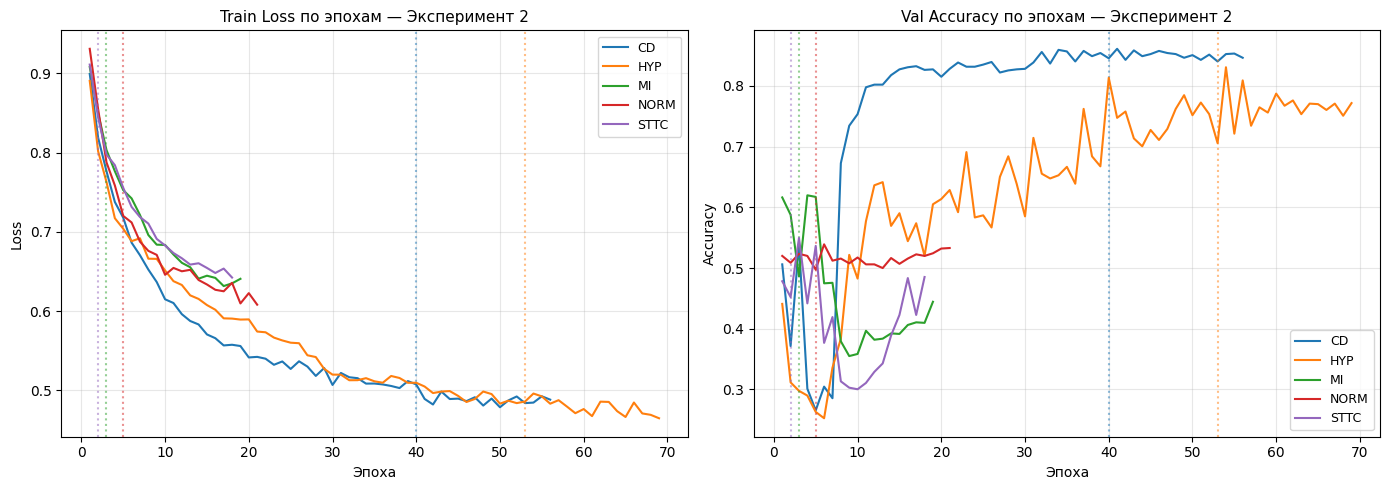

In [17]:
# кривые обучения — эксперимент 2
colors_sc = sns.color_palette("tab10", len(C.SUPERCLASSES))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sc, color in zip(C.SUPERCLASSES, colors_sc):
    hist = result_exp2["per_class"][sc]["history"]
    if hasattr(hist, "history"):
        hist = hist.history
    train_loss = hist.get("loss", [])
    val_acc = hist.get("valid_accuracy", [])
    best_ep = result_exp2["per_class"][sc]["best_epoch"]

    if train_loss:
        axes[0].plot(range(1, len(train_loss) + 1), train_loss, label=sc, color=color)
        axes[0].axvline(best_ep, color=color, linestyle=":", alpha=0.5)
    if val_acc:
        axes[1].plot(range(1, len(val_acc) + 1), val_acc, label=sc, color=color)
        axes[1].axvline(best_ep, color=color, linestyle=":", alpha=0.5)

axes[0].set_title("Train Loss по эпохам — Эксперимент 2", fontsize=11)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title("Val Accuracy по эпохам — Эксперимент 2", fontsize=11)
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы**
- модель CD снова показывает лучшие результаты: после краткой нестабильности в начале обучения accuracy быстро растёт до ~0.85–0.86 и далее остаётся стабильной. Одновременно наблюдается уверенное снижение loss, что говорит о хорошей способности модели к обобщению.
- Модель HYP обучается значительно медленнее и более шумно: validation accuracy сильно колеблется между эпохами, однако к концу обучения достигает приемлемого качества (~0.76–0.79). Это может указывать на менее стабильный процесс оптимизации.
- Модели MI, NORM и STTC показали слабые результаты: accuracy остаётся на низком уровне (~0.3–0.55), а loss снижается медленно. Особенно заметно, что данные конфигурации либо не способны эффективно обучаться в рамках данного эксперимента, либо требуют существенной настройки гиперпараметров.

In [56]:
rows_exp2 = []
for sc in C.SUPERCLASSES:
    r = result_exp2["per_class"][sc]
    rows_exp2.append({
        "Класс": sc,
        "Val F1-macro": r["val_metrics"]["f1_macro"],
        "Test F1-macro": r["test_metrics"]["f1_macro"],
        "Test PR-AUC": r["test_metrics"]["pr_auc"],
        "Test ROC-AUC": r["test_metrics"]["roc_auc"],
        "Test Accuracy": r["test_metrics"]["accuracy"],
        "Best Epoch": r["best_epoch"],
    })

metrics_exp2_df = pd.DataFrame(rows_exp2).set_index("Класс")
mean_row2 = metrics_exp2_df.select_dtypes("number").mean().to_frame("Mean").T
mean_row2.index.name = "Класс"
display(pd.concat([metrics_exp2_df, mean_row2]).style.format("{:.4f}").background_gradient(
    cmap="YlGn", subset=["Test F1-macro", "Test PR-AUC", "Test ROC-AUC"]
))

,Val F1-macro,Test F1-macro,Test PR-AUC,Test ROC-AUC,Test Accuracy,Best Epoch
Класс,,,,,,
CD,0.7805,0.7730,0.6689,0.8385,0.8511,40.0000
HYP,0.6921,0.6818,0.4320,0.8132,0.8229,53.0000
MI,0.4821,0.4840,0.2379,0.4745,0.5955,3.0000
NORM,0.4992,0.4870,0.4740,0.5829,0.5170,5.0000
STTC,0.5062,0.5177,0.3058,0.5591,0.5644,2.0000
Mean,0.5920,0.5887,0.4237,0.6537,0.6702,20.6000


**Выводы**
- Большее число параметров привело к худшим значениям метрик. Единственный класс CD показывает удовлетворительный результат, остальные три класса (MI, NORM, STTC) предсказываются на уровне случайного угадывания или чуть выше. Это обусловлено явным переобученим модели - модель имеет слишком сложную архитектуру для наших данных.

### TabNet | Оптимизированная конфигурация через Optuna
Подберем гиперпараметры автоматически, используя Optuna (оптимизируем **среднее Val F1-macro** по 5 классам)

In [21]:
seed_everything(C.SEED)

# запуск поиска гиперпараметров
best_params_optuna, optuna_study = hyperparameter_search(
    train_df=train_feat_df,
    val_df=val_feat_df,
    test_df=test_feat_df,
    features=features,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    n_trials=C.N_TRIALS,
    default_params=C.TABNET_PARAMS_DEFAULT,
)

print("\nЛучшие параметры (Optuna):")
for k, v in best_params_optuna.items():
    print(f"  {k}: {v}")
    
print(f"\nЛучший Mean Val F1-macro: {optuna_study.best_value:.4f}")

2026-05-07 17:19:17 - INFO - Seed установлен: 42
2026-05-07 17:19:17 - INFO - Запуск Optuna поиска, n_trials=5


  0%|          | 0/5 [00:00<?, ?it/s]

2026-05-07 17:19:17 - INFO - [optuna_trial_0] Обучение 5 бинарных TabNet-моделей



Early stopping occurred at epoch 37 with best_epoch = 22 and best_valid_accuracy = 0.87413


2026-05-07 17:19:56 - INFO - [optuna_trial_0/CD] Val F1-macro=0.7845  PR-AUC=0.7170  best_epoch=22


...


Early stopping occurred at epoch 33 with best_epoch = 18 and best_valid_accuracy = 0.77431


2026-05-07 17:35:42 - INFO - [optuna_trial_4/NORM] Val F1-macro=0.7741  PR-AUC=0.8285  best_epoch=18



Early stopping occurred at epoch 15 with best_epoch = 0 and best_valid_accuracy = 0.55208


2026-05-07 17:36:00 - INFO - [optuna_trial_4/STTC] Val F1-macro=0.4948  PR-AUC=0.2471  best_epoch=0
2026-05-07 17:36:00 - INFO - [optuna_trial_4] Mean Val F1-macro=0.6832  Mean Test F1-macro=0.6698
2026-05-07 17:36:00 - INFO - Лучшие параметры: {'n_d': 8, 'n_steps': 3, 'n_shared': 2, 'cat_emb_dim': 1, 'lr': 0.02, 'mask_type': 'entmax', 'lambda_sparse': 0.001, 'patience': 15, 'max_epochs': 100}
2026-05-07 17:36:00 - INFO - Лучшее Mean Val F1-macro: 0.7479



Лучшие параметры (Optuna):
  n_d: 8
  n_steps: 3
  n_shared: 2
  cat_emb_dim: 1
  lr: 0.02
  mask_type: entmax
  lambda_sparse: 0.001
  patience: 15
  max_epochs: 100
  n_a: 8

Лучший Mean Val F1-macro: 0.7479


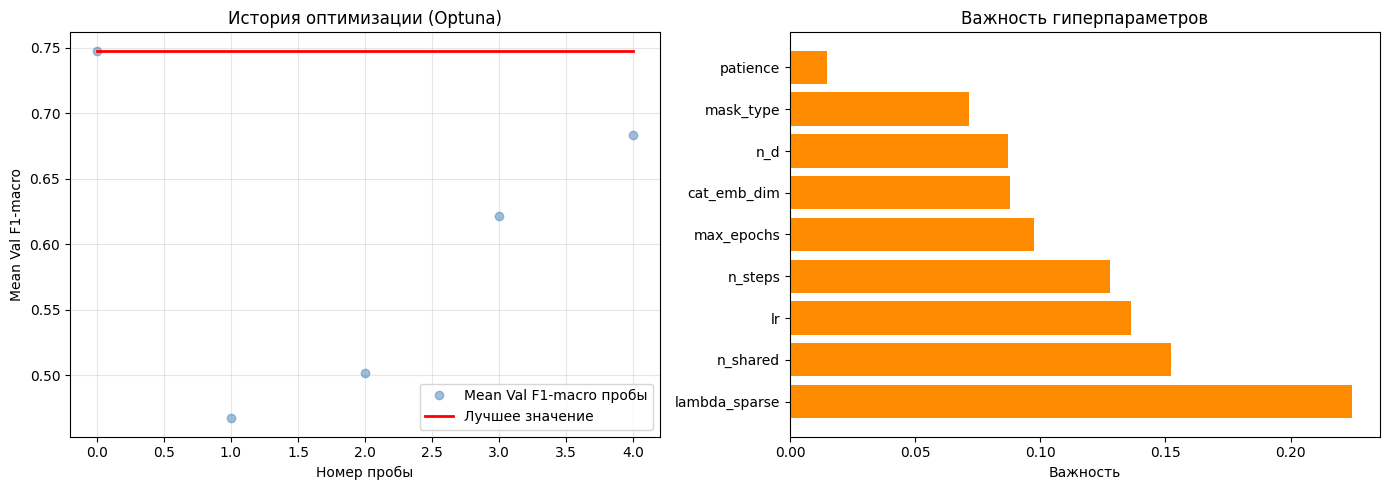

In [26]:
# истории оптимизации Optuna
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trial_values = [t.value for t in optuna_study.trials if t.value is not None]
best_so_far = [max(trial_values[: i + 1]) for i in range(len(trial_values))]
axes[0].plot(trial_values, "o", alpha=0.5, color="steelblue", label="Mean Val F1-macro пробы")
axes[0].plot(best_so_far, "-", color="red", linewidth=2, label="Лучшее значение")
axes[0].set_title("История оптимизации (Optuna)", fontsize=12)
axes[0].set_xlabel("Номер пробы")
axes[0].set_ylabel("Mean Val F1-macro")
axes[0].legend()
axes[0].grid(alpha=0.3)

try:
    import optuna
    importances = optuna.importance.get_param_importances(optuna_study)
    params_imp = list(importances.keys())
    vals_imp = list(importances.values())
    axes[1].barh(params_imp, vals_imp, color="darkorange")
    axes[1].set_title("Важность гиперпараметров", fontsize=12)
    axes[1].set_xlabel("Важность")
except Exception:
    axes[1].text(0.5, 0.5, "Недостаточно проб\nдля анализа важности",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

**Выводы**
- Возможно стоит дать больше кол-во попыток для нахождения лучших параметров
- Самыми значимые параметры: `lambda_sparce`, `n_shared`, `lr`, ...

In [27]:
seed_everything(C.SEED)

# обучаем финальную модель с лучшими параметрами от Optuna и оцениваем на тесте
params_exp3 = best_params_optuna.copy()
result_exp3 = train_tabnet_per_class(
    train_df=train_feat_df,
    val_df=val_feat_df,
    test_df=test_feat_df,
    params=params_exp3,
    features=features,
    experiment_id="exp3_optuna",
    verbose=0,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
)

print(f"\nMean Val F1-macro: {result_exp3['mean_val_f1_macro']:.4f}")
print(f"Mean Test F1-macro: {result_exp3['mean_test_f1_macro']:.4f}")
print(f"Mean Test PR-AUC: {result_exp3['mean_test_pr_auc']:.4f}")
print(f"Mean Test ROC-AUC: {result_exp3['mean_test_roc_auc']:.4f}")
print(f"Время обучения: {result_exp3['train_time']:.1f}с")

2026-05-07 17:45:51 - INFO - Seed установлен: 42
2026-05-07 17:45:51 - INFO - [exp3_optuna] Обучение 5 бинарных TabNet-моделей



Early stopping occurred at epoch 37 with best_epoch = 22 and best_valid_accuracy = 0.87413


2026-05-07 17:46:28 - INFO - [exp3_optuna/CD] Val F1-macro=0.7845  PR-AUC=0.7170  best_epoch=22



Early stopping occurred at epoch 61 with best_epoch = 46 and best_valid_accuracy = 0.87066


2026-05-07 17:47:30 - INFO - [exp3_optuna/HYP] Val F1-macro=0.7260  PR-AUC=0.5465  best_epoch=46


...


Early stopping occurred at epoch 85 with best_epoch = 70 and best_valid_accuracy = 0.8151


2026-05-07 17:49:32 - INFO - [exp3_optuna/NORM] Val F1-macro=0.8151  PR-AUC=0.8692  best_epoch=70



Early stopping occurred at epoch 74 with best_epoch = 59 and best_valid_accuracy = 0.77778


2026-05-07 17:51:05 - INFO - [exp3_optuna/STTC] Val F1-macro=0.7301  PR-AUC=0.5969  best_epoch=59
2026-05-07 17:51:05 - INFO - [exp3_optuna] Mean Val F1-macro=0.7479  Mean Test F1-macro=0.7351



Mean Val F1-macro: 0.7479
Mean Test F1-macro: 0.7351
Mean Test PR-AUC: 0.6335
Mean Test ROC-AUC: 0.8369
Время обучения: 311.1с


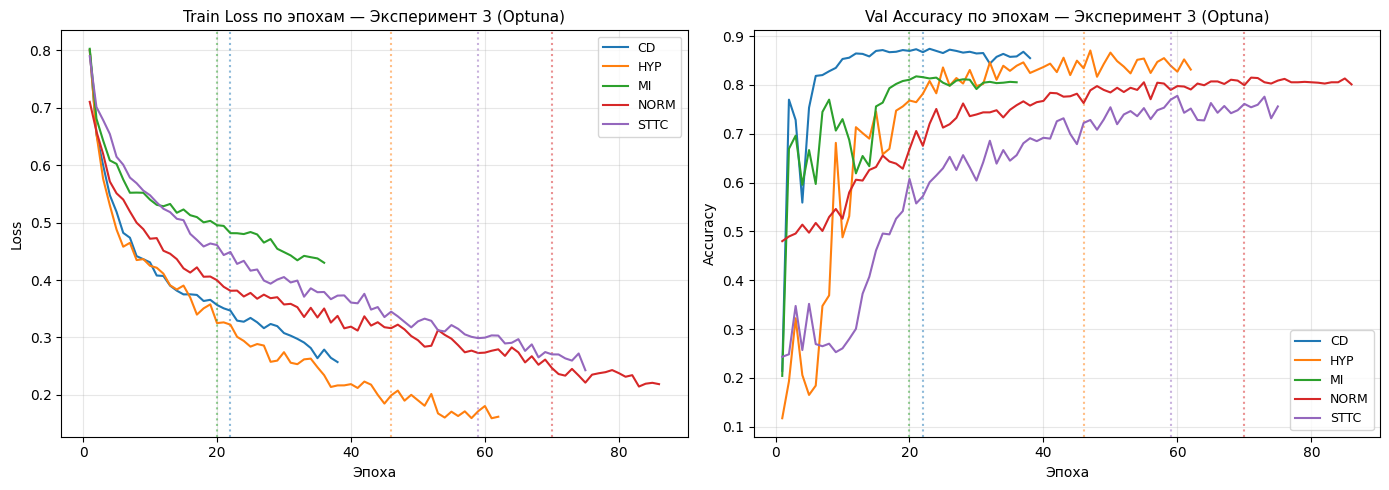

In [30]:
# кривые обучения — эксперимент 3 
colors_sc = sns.color_palette("tab10", len(C.SUPERCLASSES))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sc, color in zip(C.SUPERCLASSES, colors_sc):
    hist = result_exp3["per_class"][sc]["history"]
    if hasattr(hist, "history"):
        hist = hist.history
    train_loss = hist.get("loss", [])
    val_acc = hist.get("valid_accuracy", [])
    best_ep = result_exp3["per_class"][sc]["best_epoch"]

    if train_loss:
        axes[0].plot(range(1, len(train_loss) + 1), train_loss, label=sc, color=color)
        axes[0].axvline(best_ep, color=color, linestyle=":", alpha=0.5)
    if val_acc:
        axes[1].plot(range(1, len(val_acc) + 1), val_acc, label=sc, color=color)
        axes[1].axvline(best_ep, color=color, linestyle=":", alpha=0.5)

axes[0].set_title("Train Loss по эпохам — Эксперимент 3 (Optuna)", fontsize=11)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title("Val Accuracy по эпохам — Эксперимент 3 (Optuna)", fontsize=11)
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы**
- После подбора гиперпараметров через Optuna модели демонстрируют более стабильное обучение и высокое качество. Наилучший результат снова показывает CD, достигая validation accuracy около ~0.87 при сравнительно небольшом количестве эпох.
- Модель HYP после оптимизации существенно улучшилась: accuracy постепенно возрастает до ~0.85–0.86, а train loss продолжает уверенно снижаться. Это говорит о том, что данная конфигурация особенно чувствительна к качественному подбору гиперпараметров.
- Конфигурации NORM и STTC также улучшили качество по сравнению с менее удачными экспериментами, однако всё ещё уступают CD и HYP как по скорости сходимости, так и по итоговой accuracy. Модель MI остаётся одной из наименее эффективных, демонстрируя раннее насыщение и более высокий loss.

In [55]:
rows_exp3 = []
for sc in C.SUPERCLASSES:
    r = result_exp3["per_class"][sc]
    rows_exp3.append({
        "Класс": sc,
        "Val F1-macro": r["val_metrics"]["f1_macro"],
        "Test F1-macro": r["test_metrics"]["f1_macro"],
        "Test PR-AUC": r["test_metrics"]["pr_auc"],
        "Test ROC-AUC": r["test_metrics"]["roc_auc"],
        "Test Accuracy": r["test_metrics"]["accuracy"],
        "Best Epoch": r["best_epoch"],
    })

metrics_exp3_df = pd.DataFrame(rows_exp3).set_index("Класс")
mean_row3 = metrics_exp3_df.select_dtypes("number").mean().to_frame("Mean").T
mean_row3.index.name = "Класс"
display(pd.concat([metrics_exp3_df, mean_row3]).style.format("{:.4f}").background_gradient(
    cmap="YlGn", subset=["Test F1-macro", "Test PR-AUC", "Test ROC-AUC"]
))


,Val F1-macro,Test F1-macro,Test PR-AUC,Test ROC-AUC,Test Accuracy,Best Epoch
Класс,,,,,,
CD,0.7845,0.7877,0.7236,0.8603,0.8741,22.0000
HYP,0.7260,0.7341,0.5340,0.8446,0.8700,46.0000
MI,0.6836,0.6266,0.4529,0.7588,0.7607,20.0000
NORM,0.8151,0.7969,0.8314,0.8803,0.7974,70.0000
STTC,0.7301,0.7300,0.6256,0.8406,0.7729,59.0000
Mean,0.7479,0.7351,0.6335,0.8369,0.8150,43.4000


**Выводы**
- Несмотря на то, что модель CD показывает наивысший Test Accuracy (~0.874) и высокое Test F1-macro (~0.788), модель NORM демонстрирует лучшие показатели качества по несбалансированным классам: максимальные Val F1-macro (~0.815), Test PR-AUC (~0.831) и Test ROC-AUC (~0.880). Это указывает на более качественное разделение классов и лучшую устойчивость к дисбалансу данных.
- Модель HYP достигает высокого Accuracy (~0.870), сопоставимого с CD, однако значительно уступает по PR-AUC (~0.534). Это говорит о том, что модель хорошо предсказывает доминирующие классы, но хуже работает на редких или сложных категориях.
- Модели MI и STTC показывают наиболее слабые результаты практически по всем метрикам. Особенно заметно снижение ROC-AUC и PR-AUC у MI, что подтверждает выводы с графиков о раннем насыщении и недостаточной способности модели к обобщению.

### GANDALF | Базовая конфигурация
GANDALF (Gated Adaptive Network for Deep Automated Learning of Features) — это современная нейросетевая архитектура для работы с табличными данными. Модель использует механизм gated-слоёв (управляемых ворот), который позволяет сети автоматически определять наиболее важные признаки и эффективно обучать сложные нелинейные зависимости в данных. 

Обучим модель, используя базовые гиперпараметры

In [39]:
# параметры GANDALF — конфигурация 4 (базовая)
params_exp4 = C.GANDALF_PARAMS_DEFAULT.copy()
for k, v in params_exp4.items():
    print(f"  {k}: {v}")

  gflu_stages: 6
  gflu_dropout: 0.0
  gflu_feature_init_sparsity: 0.3
  learnable_sparsity: True
  lr: 0.001
  max_epochs: 100
  patience: 15
  batch_size: 1024


In [40]:
seed_everything(C.SEED)

# обучаем и оцениваем модель GANDALF для каждого класса
result_exp4 = train_pytorch_tabular_per_class(
    train_df=train_feat_df,
    val_df=val_feat_df,
    test_df=test_feat_df,
    params=params_exp4,
    features=features,
    model_type="gandalf",
    experiment_id="exp4_gandalf_default",
)

print(f"\nMean Val F1-macro: {result_exp4['mean_val_f1_macro']:.4f}")
print(f"Mean Test F1-macro: {result_exp4['mean_test_f1_macro']:.4f}")
print(f"Mean Test PR-AUC: {result_exp4['mean_test_pr_auc']:.4f}")
print(f"Mean Test ROC-AUC: {result_exp4['mean_test_roc_auc']:.4f}")
print(f"Время обучения: {result_exp4['train_time']:.1f}с")

2026-05-07 18:16:05 - INFO - Seed установлен: 42
2026-05-07 18:16:05 - INFO - [exp4_gandalf_default/CD] Начало обучения (gandalf)
2026-05-07 18:16:05 - INFO - Experiment Tracking is turned off
Seed set to 42
2026-05-07 18:16:05 - INFO - Preparing the DataLoaders
2026-05-07 18:16:05 - INFO - Setting up the datamodule for classification task
2026-05-07 18:16:05 - INFO - Preparing the Model: GANDALFModel
2026-05-07 18:16:05 - INFO - Preparing the Trainer
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
2026-05-07 18:16:05 - INFO - Training Started
2026-05-07 18:17:07 - INFO - Training the model completed
2026-05-07 18:17:08 - INFO - [exp4_gandalf_default/CD] Val F1-macro=0.8078  PR-AUC=0.7383  epochs=22
2026-05-07 18:17:08 - INFO - [exp4_gandalf_default/HYP] Начало обучения (gandalf)
2026-05-07 18:17:08 - INFO - Experiment Tracking is turned off
Seed set to 42
2026-05-07 18:17:08 - INFO - Pre


Mean Val F1-macro: 0.7554
Mean Test F1-macro: 0.7570
Mean Test PR-AUC: 0.6739
Mean Test ROC-AUC: 0.8543
Время обучения: 297.3с


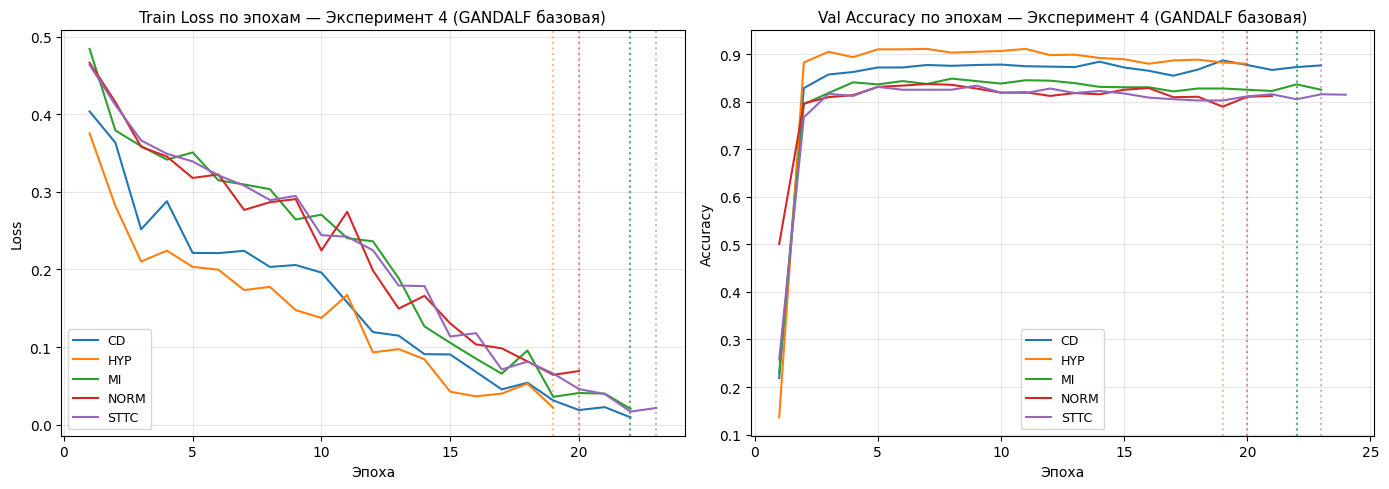

In [41]:
# кривые обучения — эксперимент 4
colors_sc = sns.color_palette("tab10", len(C.SUPERCLASSES))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sc, color in zip(C.SUPERCLASSES, colors_sc):
    hist = result_exp4["per_class"][sc]["history"]
    train_loss = hist.get("loss", [])
    val_acc = hist.get("valid_accuracy", [])
    best_ep = result_exp4["per_class"][sc]["best_epoch"]

    if train_loss:
        axes[0].plot(range(1, len(train_loss) + 1), train_loss, label=sc, color=color)
        axes[0].axvline(best_ep, color=color, linestyle=":", alpha=0.5)
    if val_acc:
        axes[1].plot(range(1, len(val_acc) + 1), val_acc, label=sc, color=color)
        axes[1].axvline(best_ep, color=color, linestyle=":", alpha=0.5)

axes[0].set_title("Train Loss по эпохам — Эксперимент 4 (GANDALF базовая)", fontsize=11)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title("Val Accuracy по эпохам — Эксперимент 4 (GANDALF базовая)", fontsize=11)
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы**
- Качество метрик быстро достигает максимума при небольшем числе эпох (1-3), в то время как лосс на валидации все еще велик - модель переобучается

In [54]:
# таблица метрик
rows_exp4 = []
for sc in C.SUPERCLASSES:
    r = result_exp4["per_class"][sc]
    rows_exp4.append({
        "Класс": sc,
        "Val F1-macro": r["val_metrics"]["f1_macro"],
        "Test F1-macro": r["test_metrics"]["f1_macro"],
        "Test PR-AUC": r["test_metrics"]["pr_auc"],
        "Test ROC-AUC": r["test_metrics"]["roc_auc"],
        "Test Accuracy": r["test_metrics"]["accuracy"],
        "Best Epoch": r["best_epoch"],
    })

metrics_exp4_df = pd.DataFrame(rows_exp4).set_index("Класс")
mean_row4 = metrics_exp4_df.select_dtypes("number").mean().to_frame("Mean").T
mean_row4.index.name = "Класс"
display(pd.concat([metrics_exp4_df, mean_row4]).style.format("{:.4f}").background_gradient(
    cmap="YlGn", subset=["Test F1-macro", "Test PR-AUC", "Test ROC-AUC"]
))

,Val F1-macro,Test F1-macro,Test PR-AUC,Test ROC-AUC,Test Accuracy,Best Epoch
Класс,,,,,,
CD,0.8078,0.8032,0.7531,0.8811,0.8693,22.0000
HYP,0.6988,0.7241,0.5152,0.8234,0.8860,19.0000
MI,0.7239,0.7135,0.6353,0.8282,0.7968,22.0000
NORM,0.8123,0.8149,0.8287,0.8904,0.8163,20.0000
STTC,0.7344,0.7295,0.6369,0.8486,0.8059,23.0000
Mean,0.7554,0.7570,0.6739,0.8543,0.8349,21.2000


**Выводы**
- В данном эксперименте модель NORM показала наилучшее общее качество: максимальный Test F1-macro (~0.815), лучший PR-AUC (~0.829) и ROC-AUC (~0.890). Это свидетельствует о наиболее сбалансированной работе модели по всем классам и высокой способности различать положительные и отрицательные примеры.
- Модель CD остаётся одной из самых сильных конфигураций, демонстрируя высокий Accuracy (~0.869) и стабильный F1-macro (~0.803). При этом она обучается быстро (Best Epoch = 22), что делает её хорошим компромиссом между качеством и скоростью обучения.
- Модель HYP достигает наивысшего Accuracy (~0.886), однако её низкий PR-AUC (~0.515) и более слабый F1-macro (~0.724) показывают, что высокая точность достигается преимущественно за счёт доминирующих классов. Это ещё раз подтверждает, что Accuracy в данной задаче не является достаточной метрикой качества.

### GANDALF | Глубокая конфигурация
Теперь усложним модель, добавив больше слоев и параметров

In [43]:
# параметры GANDALF — конфигурация 5 (глубокая)
params_exp5 = C.GANDALF_PARAMS_LARGE.copy()
for k, v in params_exp5.items():
    print(f"  {k}: {v}")

  gflu_stages: 8
  gflu_dropout: 0.1
  gflu_feature_init_sparsity: 0.5
  learnable_sparsity: True
  lr: 0.0005
  max_epochs: 100
  patience: 15
  batch_size: 1024


In [44]:
seed_everything(C.SEED)

# обучаем и оцениваем модель GANDALF для каждого класса
result_exp5 = train_pytorch_tabular_per_class(
    train_df=train_feat_df,
    val_df=val_feat_df,
    test_df=test_feat_df,
    params=params_exp5,
    features=features,
    model_type="gandalf",
    experiment_id="exp5_gandalf_large",
)

print(f"\nMean Val F1-macro: {result_exp5['mean_val_f1_macro']:.4f}")
print(f"Mean Test F1-macro: {result_exp5['mean_test_f1_macro']:.4f}")
print(f"Mean Test PR-AUC: {result_exp5['mean_test_pr_auc']:.4f}")
print(f"Mean Test ROC-AUC: {result_exp5['mean_test_roc_auc']:.4f}")
print(f"Время обучения: {result_exp5['train_time']:.1f}с")

2026-05-07 18:24:00 - INFO - Seed установлен: 42
2026-05-07 18:24:00 - INFO - [exp5_gandalf_large/CD] Начало обучения (gandalf)
2026-05-07 18:24:00 - INFO - Experiment Tracking is turned off
Seed set to 42
2026-05-07 18:24:00 - INFO - Preparing the DataLoaders
2026-05-07 18:24:00 - INFO - Setting up the datamodule for classification task
2026-05-07 18:24:00 - INFO - Preparing the Model: GANDALFModel
2026-05-07 18:24:00 - INFO - Preparing the Trainer
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
2026-05-07 18:24:00 - INFO - Training Started
2026-05-07 18:25:34 - INFO - Training the model completed
2026-05-07 18:25:34 - INFO - [exp5_gandalf_large/CD] Val F1-macro=0.8031  PR-AUC=0.7429  epochs=25
2026-05-07 18:25:34 - INFO - [exp5_gandalf_large/HYP] Начало обучения (gandalf)
2026-05-07 18:25:35 - INFO - Experiment Tracking is turned off
Seed set to 42
2026-05-07 18:25:35 - INFO - Preparing


Mean Val F1-macro: 0.7575
Mean Test F1-macro: 0.7568
Mean Test PR-AUC: 0.6908
Mean Test ROC-AUC: 0.8651
Время обучения: 489.3с


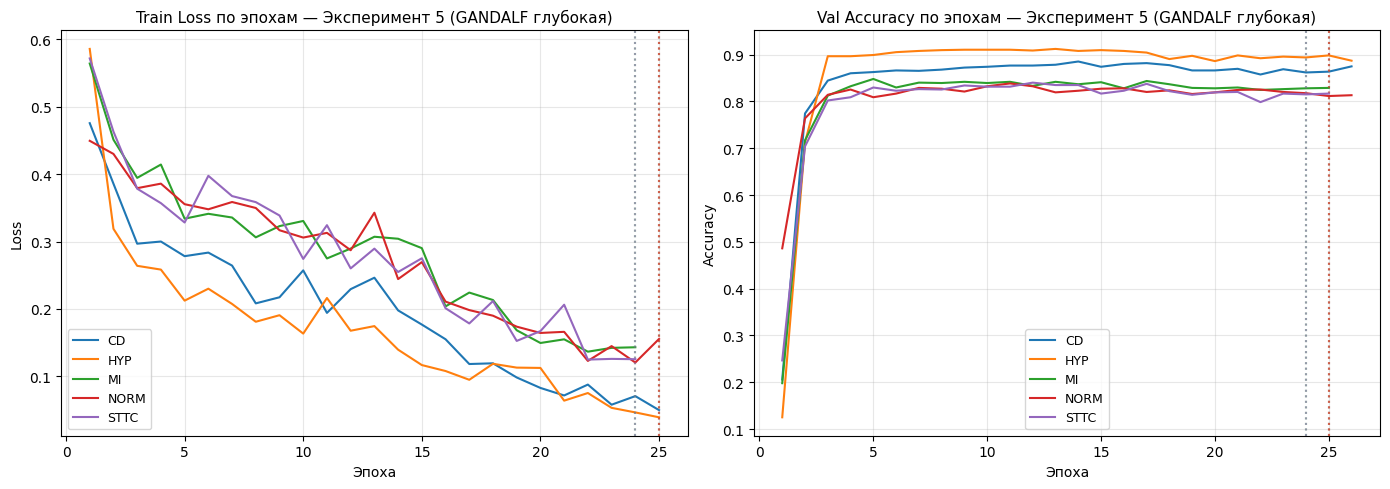

In [45]:
# кривые обучения — эксперимент 5
colors_sc = sns.color_palette("tab10", len(C.SUPERCLASSES))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sc, color in zip(C.SUPERCLASSES, colors_sc):
    hist = result_exp5["per_class"][sc]["history"]
    train_loss = hist.get("loss", [])
    val_acc = hist.get("valid_accuracy", [])
    best_ep = result_exp5["per_class"][sc]["best_epoch"]

    if train_loss:
        axes[0].plot(range(1, len(train_loss) + 1), train_loss, label=sc, color=color)
        axes[0].axvline(best_ep, color=color, linestyle=":", alpha=0.5)
    if val_acc:
        axes[1].plot(range(1, len(val_acc) + 1), val_acc, label=sc, color=color)
        axes[1].axvline(best_ep, color=color, linestyle=":", alpha=0.5)

axes[0].set_title("Train Loss по эпохам — Эксперимент 5 (GANDALF глубокая)", fontsize=11)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title("Val Accuracy по эпохам — Эксперимент 5 (GANDALF глубокая)", fontsize=11)
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы**
- Результаты аналогичны предыдущему эксперименту выше

In [53]:
# таблица метрик
rows_exp5 = []
for sc in C.SUPERCLASSES:
    r = result_exp5["per_class"][sc]
    rows_exp5.append({
        "Класс": sc,
        "Val F1-macro": r["val_metrics"]["f1_macro"],
        "Test F1-macro": r["test_metrics"]["f1_macro"],
        "Test PR-AUC": r["test_metrics"]["pr_auc"],
        "Test ROC-AUC": r["test_metrics"]["roc_auc"],
        "Test Accuracy": r["test_metrics"]["accuracy"],
        "Best Epoch": r["best_epoch"],
    })

metrics_exp5_df = pd.DataFrame(rows_exp5).set_index("Класс")
mean_row5 = metrics_exp5_df.select_dtypes("number").mean().to_frame("Mean").T
mean_row5.index.name = "Класс"
display(pd.concat([metrics_exp5_df, mean_row5]).style.format("{:.4f}").background_gradient(
    cmap="YlGn", subset=["Test F1-macro", "Test PR-AUC", "Test ROC-AUC"]
))

,Val F1-macro,Test F1-macro,Test PR-AUC,Test ROC-AUC,Test Accuracy,Best Epoch
Класс,,,,,,
CD,0.8031,0.8083,0.7588,0.8751,0.8753,25.0000
HYP,0.7104,0.6981,0.5254,0.8508,0.8785,25.0000
MI,0.7238,0.7219,0.6596,0.8384,0.8122,24.0000
NORM,0.8132,0.8097,0.8433,0.8962,0.8100,25.0000
STTC,0.7369,0.7460,0.6668,0.8651,0.8163,24.0000
Mean,0.7575,0.7568,0.6908,0.8651,0.8384,24.6000


**Выводы**
- Модель в целом сильная и стабильная: mean F1-macro ≈ 0.76, ROC-AUC ≈ 0.87, хорошо разделяет классы и уверенно работает с дисбалансом.
- Качество ограничено сложными и перекрывающимися классами (HYP, MI, STTC), тогда как классы (NORM, CD) предсказываются значительно лучше.

### GANDALF | Оптимизированная конфигурация через Optuna
Подберем гиперпараметры автоматически, используя Optuna (оптимизируем **среднее Val F1-macro** по 5 классам)

In [47]:
seed_everything(C.SEED)

# запуск поиска гиперпараметров GANDALF
best_params_gandalf, gandalf_study = hyperparameter_search_gandalf(
    train_df=train_feat_df,
    val_df=val_feat_df,
    test_df=test_feat_df,
    features=features,
    n_trials=C.N_TRIALS,
    default_params=C.GANDALF_PARAMS_DEFAULT,
)

print("\nЛучшие параметры GANDALF (Optuna):")
for k, v in best_params_gandalf.items():
    print(f"  {k}: {v}")

print(f"\nЛучший Mean Val F1-macro: {gandalf_study.best_value:.4f}")

2026-05-07 18:35:08 - INFO - Seed установлен: 42
2026-05-07 18:35:08 - INFO - Запуск Optuna GANDALF поиска, n_trials=5


  0%|          | 0/5 [00:00<?, ?it/s]

2026-05-07 18:35:08 - INFO - [optuna_gandalf_trial_0/CD] Начало обучения (gandalf)
2026-05-07 18:35:08 - INFO - Experiment Tracking is turned off
Seed set to 42
2026-05-07 18:35:08 - INFO - Preparing the DataLoaders
2026-05-07 18:35:08 - INFO - Setting up the datamodule for classification task
2026-05-07 18:35:08 - INFO - Preparing the Model: GANDALFModel
2026-05-07 18:35:08 - INFO - Preparing the Trainer
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
2026-05-07 18:35:08 - INFO - Training Started
2026-05-07 18:36:05 - INFO - Training the model completed
2026-05-07 18:36:06 - INFO - [optuna_gandalf_trial_0/CD] Val F1-macro=0.8078  PR-AUC=0.7383  epochs=22
2026-05-07 18:36:06 - INFO - [optuna_gandalf_trial_0/HYP] Начало обучения (gandalf)
2026-05-07 18:36:06 - INFO - Experiment Tracking is turned off
Seed set to 42
2026-05-07 18:36:06 - INFO - Preparing the DataLoaders
2026-05-07 18:36:06 


Лучшие параметры GANDALF (Optuna):
  gflu_stages: 7
  gflu_dropout: 0.08736874205941257
  gflu_feature_init_sparsity: 0.46711173683342766
  lr: 0.00019010245319870352
  patience: 10
  max_epochs: 50
  learnable_sparsity: True
  batch_size: 1024

Лучший Mean Val F1-macro: 0.7852


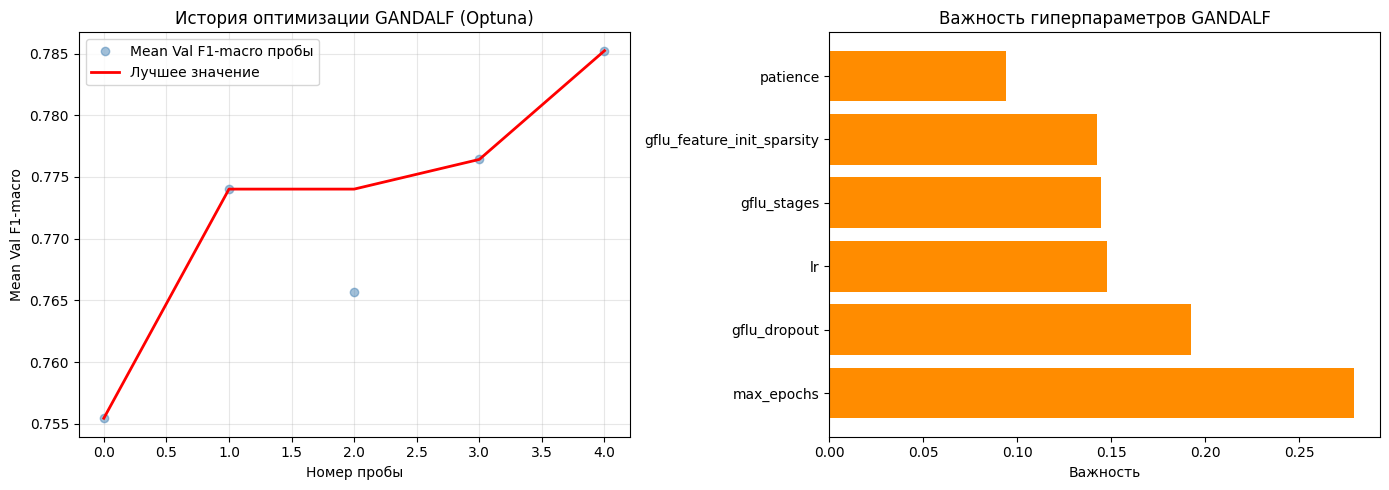

In [48]:
# история оптимизации
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trial_values = [t.value for t in gandalf_study.trials if t.value is not None]
best_so_far = [max(trial_values[: i + 1]) for i in range(len(trial_values))]
axes[0].plot(trial_values, "o", alpha=0.5, color="steelblue", label="Mean Val F1-macro пробы")
axes[0].plot(best_so_far, "-", color="red", linewidth=2, label="Лучшее значение")
axes[0].set_title("История оптимизации GANDALF (Optuna)", fontsize=12)
axes[0].set_xlabel("Номер пробы")
axes[0].set_ylabel("Mean Val F1-macro")
axes[0].legend()
axes[0].grid(alpha=0.3)

try:
    import optuna as _optuna
    importances = _optuna.importance.get_param_importances(gandalf_study)
    params_imp = list(importances.keys())
    vals_imp = list(importances.values())
    axes[1].barh(params_imp, vals_imp, color="darkorange")
    axes[1].set_title("Важность гиперпараметров GANDALF", fontsize=12)
    axes[1].set_xlabel("Важность")
except Exception:
    axes[1].text(0.5, 0.5, "Недостаточно проб\nдля анализа важности",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

**Выводы**
- Модель довольно неплохо оптимизирует гиперпараметры в нужном направлении от итерации к итерации
- Наиболее значимыми гиперпараметрами являются: `gflu_dropout`, `lr`, `gflu_stages`, ...

In [49]:
seed_everything(C.SEED)

# обучаем финальную модель GANDALF с лучшими параметрами от Optuna
params_exp6 = best_params_gandalf.copy()
result_exp6 = train_pytorch_tabular_per_class(
    train_df=train_feat_df,
    val_df=val_feat_df,
    test_df=test_feat_df,
    params=params_exp6,
    features=features,
    model_type="gandalf",
    experiment_id="exp6_gandalf_optuna",
)

print(f"\nMean Val F1-macro: {result_exp6['mean_val_f1_macro']:.4f}")
print(f"Mean Test F1-macro: {result_exp6['mean_test_f1_macro']:.4f}")
print(f"Mean Test PR-AUC: {result_exp6['mean_test_pr_auc']:.4f}")
print(f"Mean Test ROC-AUC: {result_exp6['mean_test_roc_auc']:.4f}")
print(f"Время обучения: {result_exp6['train_time']:.1f}с")

2026-05-07 19:00:31 - INFO - Seed установлен: 42
2026-05-07 19:00:31 - INFO - [exp6_gandalf_optuna/CD] Начало обучения (gandalf)
2026-05-07 19:00:31 - INFO - Experiment Tracking is turned off
Seed set to 42
2026-05-07 19:00:31 - INFO - Preparing the DataLoaders
2026-05-07 19:00:31 - INFO - Setting up the datamodule for classification task
2026-05-07 19:00:31 - INFO - Preparing the Model: GANDALFModel
2026-05-07 19:00:31 - INFO - Preparing the Trainer
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
2026-05-07 19:00:32 - INFO - Training Started
2026-05-07 19:01:48 - INFO - Training the model completed
2026-05-07 19:01:49 - INFO - [exp6_gandalf_optuna/CD] Val F1-macro=0.8197  PR-AUC=0.7600  epochs=22
2026-05-07 19:01:49 - INFO - [exp6_gandalf_optuna/HYP] Начало обучения (gandalf)
2026-05-07 19:01:49 - INFO - Experiment Tracking is turned off
Seed set to 42
2026-05-07 19:01:49 - INFO - Prepar


Mean Val F1-macro: 0.7852
Mean Test F1-macro: 0.7792
Mean Test PR-AUC: 0.7278
Mean Test ROC-AUC: 0.8831
Время обучения: 434.5с


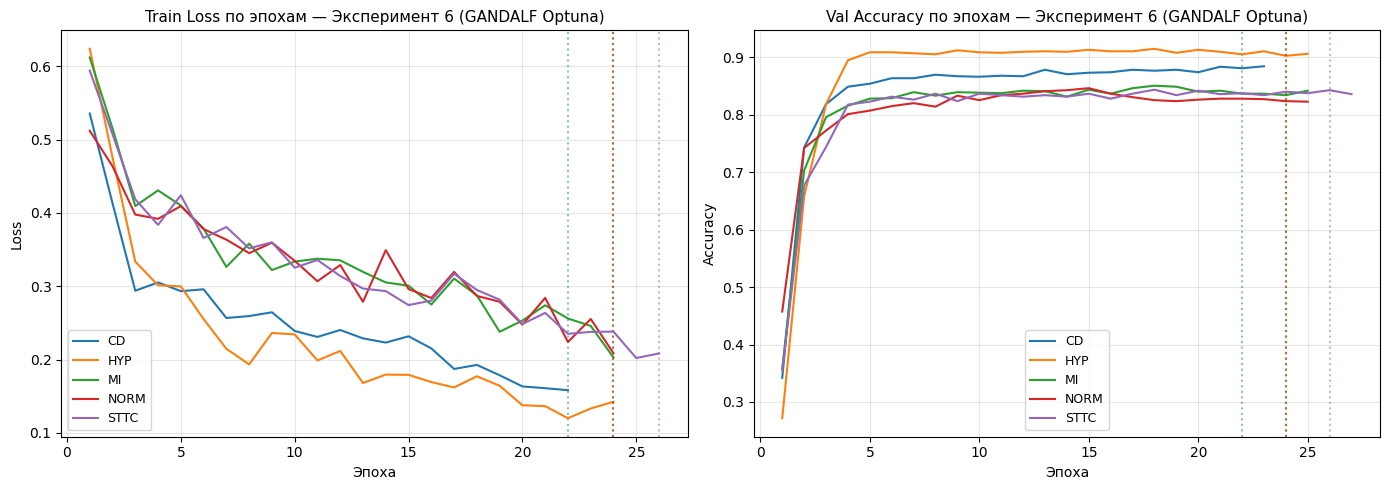

In [51]:
# кривые обучения — эксперимент 6
colors_sc = sns.color_palette("tab10", len(C.SUPERCLASSES))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sc, color in zip(C.SUPERCLASSES, colors_sc):
    hist = result_exp6["per_class"][sc]["history"]
    train_loss = hist.get("loss", [])
    val_acc = hist.get("valid_accuracy", [])
    best_ep = result_exp6["per_class"][sc]["best_epoch"]

    if train_loss:
        axes[0].plot(range(1, len(train_loss) + 1), train_loss, label=sc, color=color)
        axes[0].axvline(best_ep, color=color, linestyle=":", alpha=0.5)
    if val_acc:
        axes[1].plot(range(1, len(val_acc) + 1), val_acc, label=sc, color=color)
        axes[1].axvline(best_ep, color=color, linestyle=":", alpha=0.5)

axes[0].set_title("Train Loss по эпохам — Эксперимент 6 (GANDALF Optuna)", fontsize=11)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title("Val Accuracy по эпохам — Эксперимент 6 (GANDALF Optuna)", fontsize=11)
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы**
- Мерики максимизируются за пару эпох, как ранее

In [52]:
# таблица метрик
rows_exp6 = []
for sc in C.SUPERCLASSES:
    r = result_exp6["per_class"][sc]
    rows_exp6.append({
        "Класс": sc,
        "Val F1-macro": r["val_metrics"]["f1_macro"],
        "Test F1-macro": r["test_metrics"]["f1_macro"],
        "Test PR-AUC": r["test_metrics"]["pr_auc"],
        "Test ROC-AUC": r["test_metrics"]["roc_auc"],
        "Test Accuracy": r["test_metrics"]["accuracy"],
        "Best Epoch": r["best_epoch"],
    })

metrics_exp6_df = pd.DataFrame(rows_exp6).set_index("Класс")
mean_row6 = metrics_exp6_df.select_dtypes("number").mean().to_frame("Mean").T
mean_row6.index.name = "Класс"
display(pd.concat([metrics_exp6_df, mean_row6]).style.format("{:.4f}").background_gradient(
    cmap="YlGn", subset=["Test F1-macro", "Test PR-AUC", "Test ROC-AUC"]
))

,Val F1-macro,Test F1-macro,Test PR-AUC,Test ROC-AUC,Test Accuracy,Best Epoch
Класс,,,,,,
CD,0.8197,0.8189,0.7847,0.8901,0.8822,22.0000
HYP,0.7611,0.7509,0.6136,0.8822,0.8989,24.0000
MI,0.7520,0.7356,0.6637,0.8463,0.8150,24.0000
NORM,0.8229,0.8217,0.8823,0.9126,0.8222,24.0000
STTC,0.7705,0.7689,0.6948,0.8846,0.8313,26.0000
Mean,0.7852,0.7792,0.7278,0.8831,0.8499,24.0000


**Выводы**
- Модель демонстрирует высокое и сбалансированное качество по всем классам: mean F1-macro ≈ 0.78 и ROC-AUC ≈ 0.88, без выраженно слабых суперклассов.
- Лучше всего предсказываются NORM и CD, тогда как HYP и MI остаются наиболее сложными из-за частичного перекрытия признаков между патологиями.

### Итоговая таблица результатов экспериментов


In [58]:
def _params_str(params: dict) -> str:
    # TabNet keys
    tabnet_keys = ["n_d", "n_steps", "n_shared", "mask_type", "lr", "lambda_sparse"]
    tabnet_parts = [f"{k}={params[k]}" for k in tabnet_keys if k in params]
    if tabnet_parts:
        return "; ".join(tabnet_parts)
    # GANDALF keys
    gf_keys = ["gflu_stages", "gflu_dropout", "gflu_feature_init_sparsity", "lr"]
    gf_parts = [f"{k}={params[k]}" for k in gf_keys if k in params]
    return "; ".join(gf_parts)


experiments_meta = [
    ("Exp-1 (TabNet базовая)", params_exp1, result_exp1, "TabNet — базовые параметры"),
    ("Exp-2 (TabNet глубокая)", params_exp2, result_exp2, "TabNet — увеличенная ёмкость"),
    ("Exp-3 (TabNet Optuna)", params_exp3, result_exp3, "TabNet — оптимизировано Optuna"),
    ("Exp-4 (GANDALF базовая)", params_exp4, result_exp4, "GANDALF — базовые параметры"),
    ("Exp-5 (GANDALF глубокая)", params_exp5, result_exp5, "GANDALF — увеличенная ёмкость"),
    ("Exp-6 (GANDALF Optuna)", params_exp6, result_exp6, "GANDALF — оптимизировано Optuna"),
]

rows = []
for exp_name, params, result, note in experiments_meta:
    rows.append({
        "Эксперимент": exp_name,
        "Гиперпараметры": _params_str(params),
        "Mean Test F1-macro": result["mean_test_f1_macro"],
        "Mean Val F1-macro": result["mean_val_f1_macro"],
        "Mean Test PR-AUC": result["mean_test_pr_auc"],
        "Mean Test ROC-AUC": result["mean_test_roc_auc"],
        "Время обучения (с)": round(result["train_time"], 1),
        "Параметров (1 модель)": result["n_params"],
        "Примечания": note,
    })

comparison_df = pd.DataFrame(rows).set_index("Эксперимент")
display(comparison_df.style.format({
    c: "{:.4f}" for c in ["Mean Test F1-macro", "Mean Val F1-macro",
                           "Mean Test PR-AUC", "Mean Test ROC-AUC"]
}).background_gradient(
    cmap="YlGn",
    subset=["Mean Test F1-macro", "Mean Test PR-AUC"],
))

,Гиперпараметры,Mean Test F1-macro,Mean Val F1-macro,Mean Test PR-AUC,Mean Test ROC-AUC,Время обучения (с),Параметров (1 модель),Примечания
Эксперимент,,,,,,,,
Exp-1 (TabNet базовая),n_d=8; n_steps=3; n_shared=2; mask_type=entmax; lr=0.02; lambda_sparse=0.001,0.7351,0.7479,0.6335,0.8369,293.100000,30266,TabNet — базовые параметры
Exp-2 (TabNet глубокая),n_d=16; n_steps=5; n_shared=3; mask_type=sparsemax; lr=0.005; lambda_sparse=0.0005,0.5887,0.5920,0.4237,0.6537,302.200000,91478,TabNet — увеличенная ёмкость
Exp-3 (TabNet Optuna),n_d=8; n_steps=3; n_shared=2; mask_type=entmax; lr=0.02; lambda_sparse=0.001,0.7351,0.7479,0.6335,0.8369,311.100000,30266,TabNet — оптимизировано Optuna
Exp-4 (GANDALF базовая),lr=0.001,0.7570,0.7554,0.6739,0.8543,297.300000,5019098,GANDALF — базовые параметры
Exp-5 (GANDALF глубокая),lr=0.0005,0.7568,0.7575,0.6908,0.8651,489.300000,6691632,GANDALF — увеличенная ёмкость
Exp-6 (GANDALF Optuna),lr=0.00019010245319870352,0.7792,0.7852,0.7278,0.8831,434.500000,5855365,GANDALF — оптимизировано Optuna


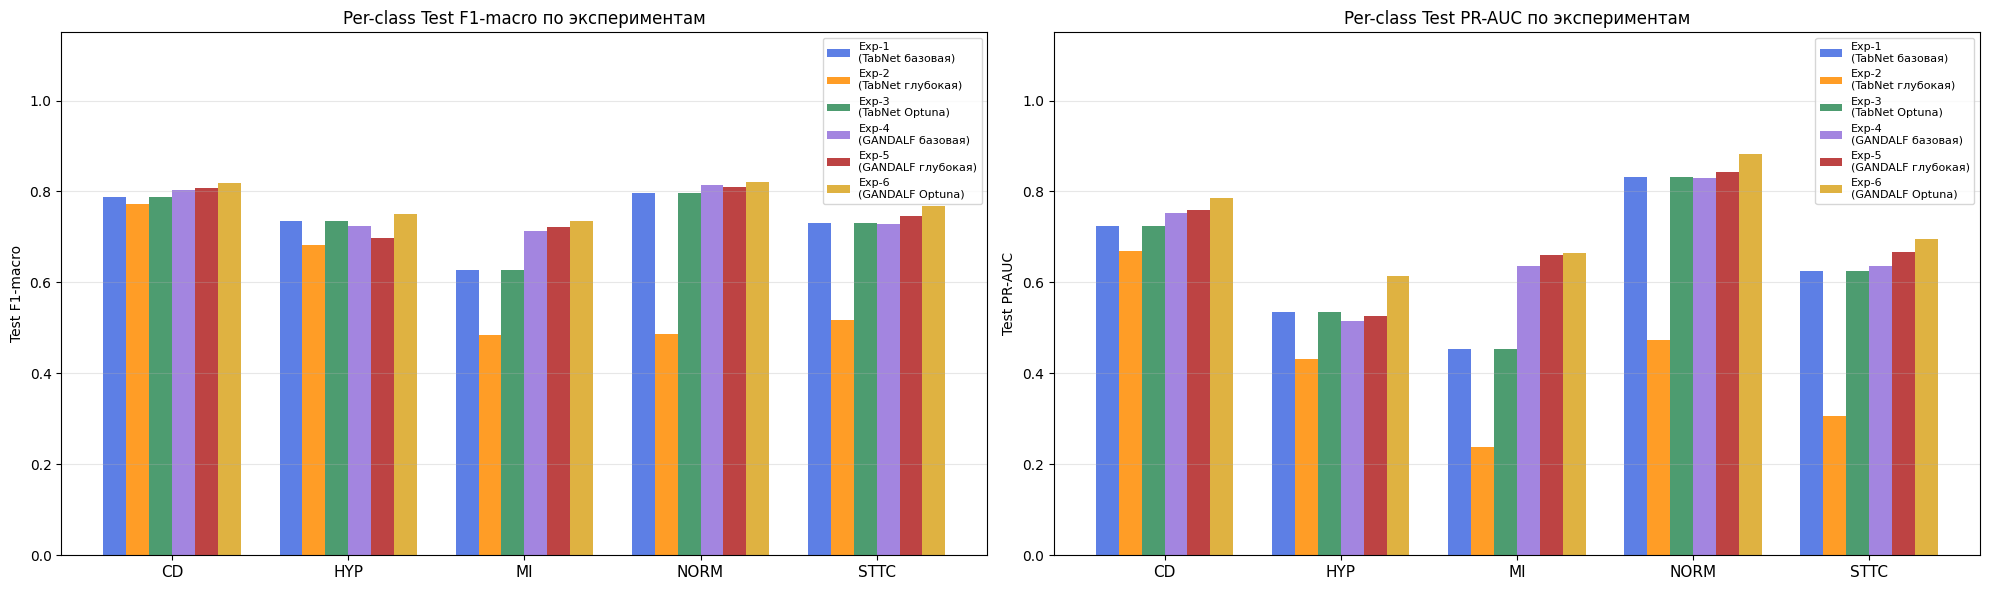

In [59]:
all_results = [result_exp1, result_exp2, result_exp3, result_exp4, result_exp5, result_exp6]
all_labels = [
    "Exp-1\n(TabNet базовая)",
    "Exp-2\n(TabNet глубокая)",
    "Exp-3\n(TabNet Optuna)",
    "Exp-4\n(GANDALF базовая)",
    "Exp-5\n(GANDALF глубокая)",
    "Exp-6\n(GANDALF Optuna)",
]
all_colors = ["royalblue", "darkorange", "seagreen", "mediumpurple", "firebrick", "goldenrod"]

x = np.arange(len(C.SUPERCLASSES))
width = 0.13

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for i, (result, color, label) in enumerate(zip(all_results, all_colors, all_labels)):
    f1_vals = [result["per_class"][sc]["test_metrics"]["f1_macro"] for sc in C.SUPERCLASSES]
    axes[0].bar(x + i * width, f1_vals, width, label=label, color=color, alpha=0.85)

axes[0].set_xticks(x + width * 2.5)
axes[0].set_xticklabels(C.SUPERCLASSES, fontsize=11)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Test F1-macro")
axes[0].set_title("Per-class Test F1-macro по экспериментам", fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

for i, (result, color, label) in enumerate(zip(all_results, all_colors, all_labels)):
    pr_vals = [result["per_class"][sc]["test_metrics"]["pr_auc"] for sc in C.SUPERCLASSES]
    axes[1].bar(x + i * width, pr_vals, width, label=label, color=color, alpha=0.85)

axes[1].set_xticks(x + width * 2.5)
axes[1].set_xticklabels(C.SUPERCLASSES, fontsize=11)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel("Test PR-AUC")
axes[1].set_title("Per-class Test PR-AUC по экспериментам", fontsize=12)
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы**
- В среднем заметно, что модель GANDALF превосходит TabNet

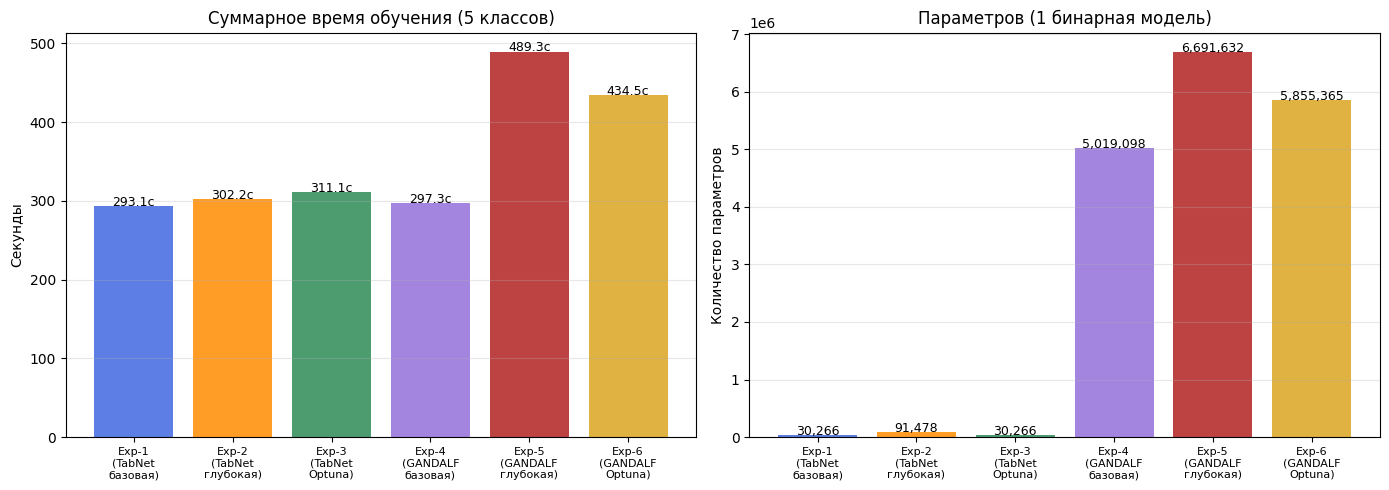

In [60]:
# Время обучения и количество параметров по экспериментам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exp_names_short = [r["Эксперимент"].replace(" ", "\n") for r in rows]
train_times = [r["Время обучения (с)"] for r in rows]
n_params_list = [r["Параметров (1 модель)"] for r in rows]
bar_colors = ["royalblue", "darkorange", "seagreen", "mediumpurple", "firebrick", "goldenrod"]

axes[0].bar(range(len(exp_names_short)), train_times, color=bar_colors, alpha=0.85)
axes[0].set_xticks(range(len(exp_names_short)))
axes[0].set_xticklabels(exp_names_short, fontsize=8)
axes[0].set_title("Суммарное время обучения (5 классов)", fontsize=12)
axes[0].set_ylabel("Секунды")
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(train_times):
    axes[0].text(i, v + 0.5, f"{v:.1f}с", ha="center", fontsize=9)

axes[1].bar(range(len(exp_names_short)), n_params_list, color=bar_colors, alpha=0.85)
axes[1].set_xticks(range(len(exp_names_short)))
axes[1].set_xticklabels(exp_names_short, fontsize=8)
axes[1].set_title("Параметров (1 бинарная модель)", fontsize=12)
axes[1].set_ylabel("Количество параметров")
axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(n_params_list):
    axes[1].text(i, v + 10, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [61]:
best_idx = comparison_df["Mean Test F1-macro"].idxmax()
best_f1 = comparison_df.loc[best_idx, "Mean Test F1-macro"]
best_pr = comparison_df.loc[best_idx, "Mean Test PR-AUC"]
best_roc = comparison_df.loc[best_idx, "Mean Test ROC-AUC"]

print(f"Лучший эксперимент: {best_idx}")
print(f"  Mean Test F1-macro : {best_f1:.4f}")
print(f"  Mean Test PR-AUC   : {best_pr:.4f}")
print(f"  Mean Test ROC-AUC  : {best_roc:.4f}")

print("\nРейтинг всех экспериментов по Mean Test F1-macro:")
print(comparison_df["Mean Test F1-macro"].sort_values(ascending=False).to_string())

best_result = {
    "Exp-1 (TabNet базовая)": result_exp1,
    "Exp-2 (TabNet глубокая)": result_exp2,
    "Exp-3 (TabNet Optuna)": result_exp3,
    "Exp-4 (GANDALF базовая)": result_exp4,
    "Exp-5 (GANDALF глубокая)": result_exp5,
    "Exp-6 (GANDALF Optuna)": result_exp6,
}[best_idx]

Лучший эксперимент: Exp-6 (GANDALF Optuna)
  Mean Test F1-macro : 0.7792
  Mean Test PR-AUC   : 0.7278
  Mean Test ROC-AUC  : 0.8831

Рейтинг всех экспериментов по Mean Test F1-macro:
Эксперимент
Exp-6 (GANDALF Optuna)      0.779193
Exp-4 (GANDALF базовая)     0.757043
Exp-5 (GANDALF глубокая)    0.756777
Exp-1 (TabNet базовая)      0.735060
Exp-3 (TabNet Optuna)       0.735060
Exp-2 (TabNet глубокая)     0.588678


### Финальные выводы
- Увеличение размера TabNet (Exp-2) приводит к катастрофическому переобучению. Часть классов (MI, NORM, STTC) останавливается уже на 2–5 эпохе, а Test F1-macro падает до 0.48–0.52 — уровень, сопоставимый со случайным угадыванием. Причина: при ~21 000 обучающих примерах модель с 91 478 параметрами имеет слишком большую ёмкость без достаточной регуляризации.
- Optuna для TabNet нашла те же параметры, что и базовые (Exp-3 = Exp-1). Это означает, что пространство гиперпараметров TabNet для данного датасета практически исчерпано: модель достигла своего предела качества (~0.735 F1-macro) независимо от настройки.
- Модель GANDALF стабильно превосходит TabNet во всех конфигурациях — даже базовая конфигурация GANDALF (Exp-4, 0.757) обходит лучший TabNet (Exp-1/3, 0.735).
- Оптимизация гиперпараметров GANDALF через Optuna даёт заметный прирост (+0.022 F1, +0.037 PR-AUC относительно базовой конфигурации), что указывает на большую чувствительность архитектуры к подбору `gflu_dropout` и `lr`.

**Почему GANDALF оказался лучше TabNet на данной задаче?**

Скорее всего дела в самой архитектуре сети:

- **TabNet** строится на последовательных шагах attention-масок: на каждом шаге модель выбирает подмножество признаков и обрабатывает его через FC-блок. Это эффективно для задач с явной признаковой разреженностью, но требует большого числа данных для обучения масок внимания. При небольших датасетах (~21K примеров) механизм масок не успевает сойтись корректно — внимание «размывается» по всем признакам.

- **GANDALF** использует Gated Feature Learning Units (GFLU): каждый слой применяет обучаемые ворота (sigmoid gate), которые мягко взвешивают каждый признак на каждом шаге. Такая структура проще оптимизируется градиентным спуском и более устойчива к малому объёму данных. Кроме того, GANDALF значительно глубже по числу параметров (~5M vs ~30K), что позволяет извлекать более сложные нелинейные взаимодействия между ЭКГ-признаками.

Также влияет специфика решаемой задачи:

- ЭКГ-признаки (~220 признаков на основе сигналов из 12 отведений) не являются разреженными — все они несут информацию. Это делает подход TabNet с «выбором подмножества признаков» менее эффективным, так как его основная сила проявляется именно при работе с разреженными или нерелевантными признаками.

- Дисбаланс классов (особенно для HYP и MI с соотношением ~4:1 и ~6:1) сильнее сказывается на TabNet, у которого меньше ёмкости для моделирования minority-класса.

GANDALF лучше подходит для задач с плотными (non-sparse) признаковыми представлениями, умеренным объёмом данных и значительным дисбалансом классов — что точно соответствует условиям данного эксперимента.


**Результаты по классам**

| Класс | Test F1-macro | Число лучших эпох |
|---|---|---|
| NORM | 0.8217 | 24 |
| CD | 0.8189 | 22 |
| STTC | 0.7689 | 26 |
| HYP | 0.7509 | 24 |
| MI | 0.7356 | 24 |

Классы NORM и CD предсказываются лучше всего — они имеют более чёткую разделимость в признаковом пространстве. HYP и MI остаются наиболее сложными: признаки этих патологий частично перекрываются с другими классами, что ограничивает максимально достижимое качество.